# Task 1: Exploratory Data Analysis and Data Preprocessing

## CFPB Complaints Dataset Analysis for CrediTrust Financial

**Objective**: Analyze and preprocess customer complaints data to prepare for the RAG complaint chatbot.

**Key Tasks**:
1. Load and explore the CFPB complaint dataset
2. Analyze product distribution
3. Analyze narrative length distribution
4. Identify missing data
5. Filter and clean the dataset
6. Save preprocessed data

---

## 1. Setup and Imports

Import required libraries and modules from our `src/` directory.

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import warnings

# Add src to path
sys.path.append(str(Path.cwd().parent))

# Import our custom modules
from src.data_loader import CFPBDataLoader
from src.eda_analyzer import EDAAnalyzer
from src.data_preprocessor import DataPreprocessor

# Configure matplotlib and seaborn
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
warnings.filterwarnings('ignore')

print("✅ All modules imported successfully!")

✅ All modules imported successfully!


## 2. Load the Dataset

Using the `CFPBDataLoader` module to load the complaints dataset.

In [6]:
# Define data path
DATA_PATH = Path.cwd().parent / 'data' / 'raw' / 'complaints.csv'

# Initialize loader and load data
print(f"Loading data from: {DATA_PATH}")
loader = CFPBDataLoader(DATA_PATH)
df = loader.load_raw_data(nrows=1000000)

print(f"\n✅ Loaded {len(df):,} complaints")
print(f"📊 Dataset shape: {df.shape}")

INFO:src.data_loader:Initialized CFPBDataLoader with data path: /home/voldi/Projects/ai-ml/rag-complaint-chatbot/data/raw/complaints.csv
INFO:src.data_loader:Loading data from /home/voldi/Projects/ai-ml/rag-complaint-chatbot/data/raw/complaints.csv


Loading data from: /home/voldi/Projects/ai-ml/rag-complaint-chatbot/data/raw/complaints.csv


INFO:src.data_loader:Successfully loaded 1000000 records



✅ Loaded 1,000,000 complaints
📊 Dataset shape: (1000000, 18)


In [7]:
# Validate the loaded data
validation_report = loader.validate_data()

print("\n📋 Validation Report:")
print(f"   • Required columns present: {validation_report['required_columns_present']}")
print(f"   • Duplicate complaint IDs: {validation_report['duplicate_complaint_ids']}")

# Display sample data
print("\n📊 Sample Data:")
df.head()

INFO:src.data_loader:Data Validation Report:
INFO:src.data_loader:  - Shape: (1000000, 18)
INFO:src.data_loader:  - Required columns present: True



📋 Validation Report:
   • Required columns present: True
   • Duplicate complaint IDs: 0

📊 Sample Data:


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


## 3. Exploratory Data Analysis

Using the `EDAAnalyzer` module to perform comprehensive analysis.

In [8]:
# Initialize EDA Analyzer
analyzer = EDAAnalyzer(df)

print("✅ EDA Analyzer initialized")

INFO:src.eda_analyzer:Initialized EDA Analyzer with 1000000 records


✅ EDA Analyzer initialized


### 3.1 Product Distribution Analysis

INFO:src.eda_analyzer:Analyzed distribution across 20 product categories


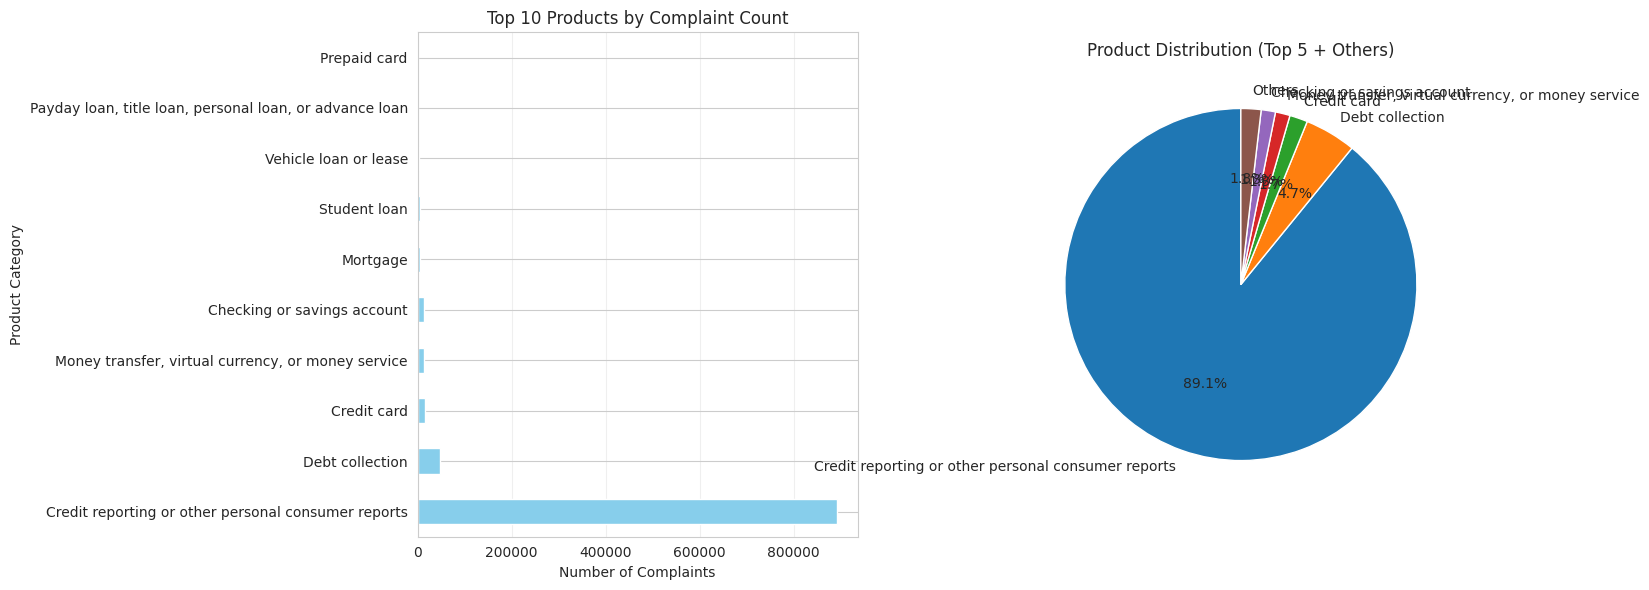


📊 Product Distribution Summary (Top 10):
                                                          Count  Percentage
Product                                                                    
Credit reporting or other personal consumer reports      891219     89.1219
Debt collection                                           47270      4.7270
Credit card                                               16530      1.6530
Money transfer, virtual currency, or money service        13430      1.3430
Checking or savings account                               13091      1.3091
Mortgage                                                   4737      0.4737
Student loan                                               4441      0.4441
Vehicle loan or lease                                      3426      0.3426
Payday loan, title loan, personal loan, or advance loan    1972      0.1972
Prepaid card                                               1085      0.1085


In [9]:
# Analyze product distribution
product_dist = analyzer.analyze_product_distribution(plot=True)

print("\n📊 Product Distribution Summary (Top 10):")
print(product_dist.head(10).to_string())

### 3.2 Narrative Length Analysis

INFO:src.eda_analyzer:Narrative length analysis: Mean=167.4, Median=108.0
INFO:src.eda_analyzer:Very short (<10 words): 396 (0.27%)
INFO:src.eda_analyzer:Very long (>500 words): 6186 (4.23%)


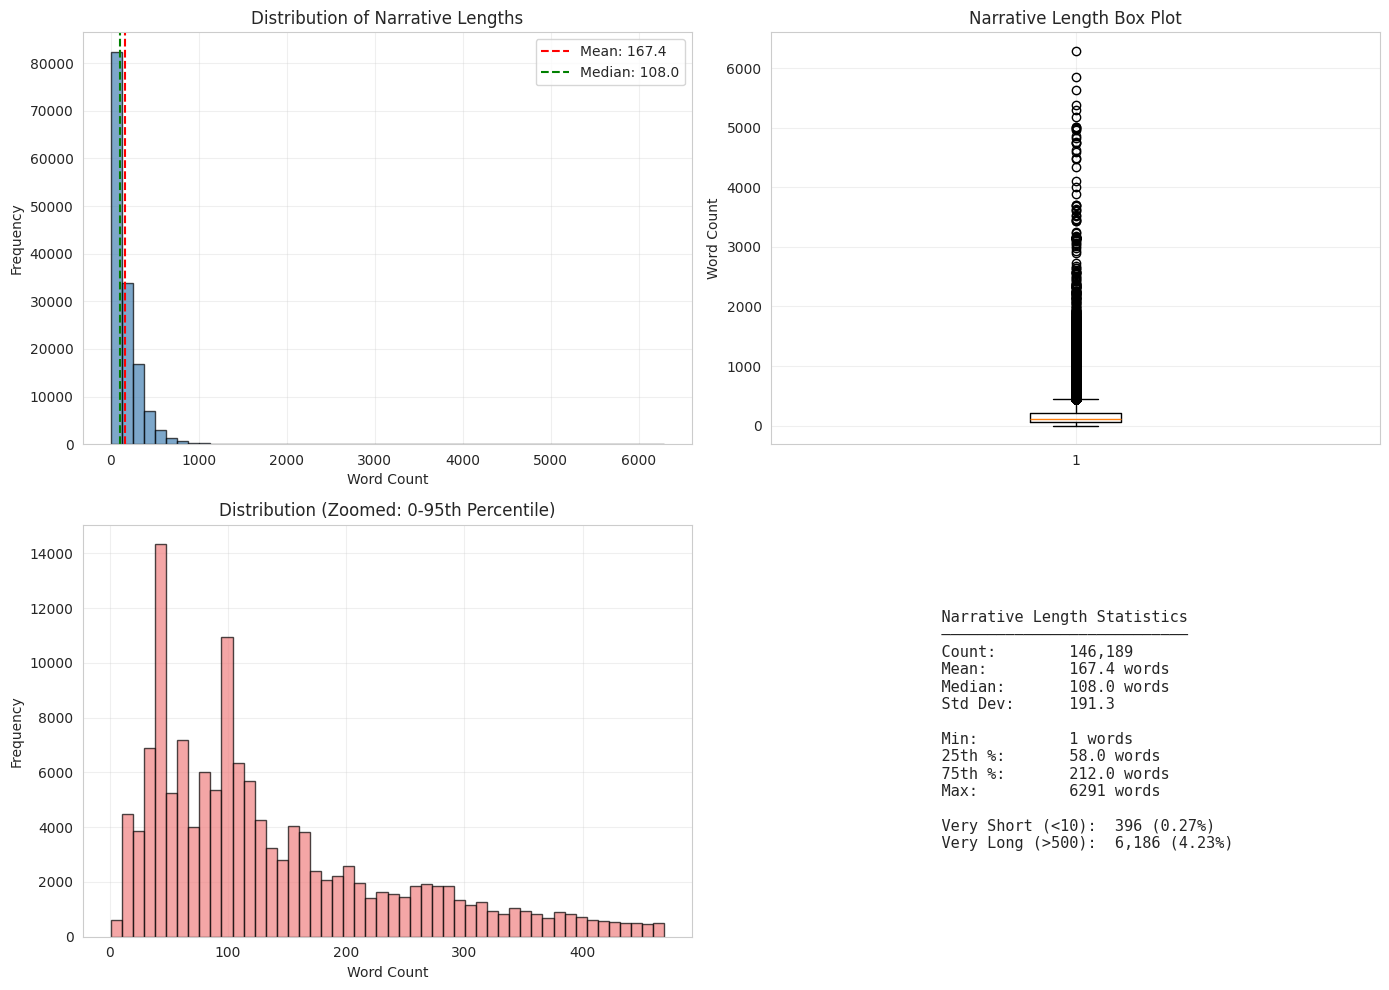


📏 Narrative Length Statistics:


In [10]:
# Analyze narrative lengths
narrative_stats = analyzer.analyze_narrative_length(plot=True)

print("\n📏 Narrative Length Statistics:")

### 3.3 Missing Narrative Analysis

In [11]:
# Identify missing narratives
missing_info = analyzer.identify_missing_narratives()

print(f"\n🔍 Missing Narrative Summary:")
print(f"   • Total Complaints: {missing_info['total_complaints']:,}")
print(f"   • With Narrative: {missing_info['with_narrative']:,} ({missing_info['with_narrative_pct']:.2f}%)")
print(f"   • Without Narrative: {missing_info['without_narrative']:,} ({missing_info['without_narrative_pct']:.2f}%)")

INFO:src.eda_analyzer:Missing narrative analysis:
INFO:src.eda_analyzer:  Total complaints: 1,000,000
INFO:src.eda_analyzer:  With narrative: 146,189 (14.62%)
INFO:src.eda_analyzer:  Without narrative: 853,811 (85.38%)



🔍 Missing Narrative Summary:
   • Total Complaints: 1,000,000
   • With Narrative: 146,189 (14.62%)
   • Without Narrative: 853,811 (85.38%)


### 3.4 Generate Comprehensive EDA Report

In [12]:
# Generate and display EDA report
eda_report = analyzer.generate_eda_report()
print(eda_report)

INFO:src.eda_analyzer:Analyzed distribution across 20 product categories
INFO:src.eda_analyzer:Narrative length analysis: Mean=167.4, Median=108.0
INFO:src.eda_analyzer:Very short (<10 words): 396 (0.27%)
INFO:src.eda_analyzer:Very long (>500 words): 6186 (4.23%)
INFO:src.eda_analyzer:Missing narrative analysis:
INFO:src.eda_analyzer:  Total complaints: 1,000,000
INFO:src.eda_analyzer:  With narrative: 146,189 (14.62%)
INFO:src.eda_analyzer:  Without narrative: 853,811 (85.38%)


CFPB COMPLAINTS - EXPLORATORY DATA ANALYSIS REPORT

1. DATASET OVERVIEW
----------------------------------------------------------------------
Total Records: 1,000,000
Total Columns: 18
Columns: Date received, Product, Sub-product, Issue, Sub-issue, Consumer complaint narrative, Company public response, Company, State, ZIP code, Tags, Consumer consent provided?, Submitted via, Date sent to company, Company response to consumer, Timely response?, Consumer disputed?, Complaint ID

2. PRODUCT DISTRIBUTION
----------------------------------------------------------------------
Credit reporting or other personal consumer reports: 891,219.0 (89.12%)
Debt collection                                   : 47,270.0 ( 4.73%)
Credit card                                       : 16,530.0 ( 1.65%)
Money transfer, virtual currency, or money service: 13,430.0 ( 1.34%)
Checking or savings account                       : 13,091.0 ( 1.31%)
Mortgage                                          :  4,737.0 ( 0.47%)

## 4. Data Preprocessing

Using the `DataPreprocessor` module to filter and clean the dataset.

In [13]:
# Initialize preprocessor with target products for CrediTrust Financial
target_products = [
    'Credit card',
    'Credit card or prepaid card',
    'Prepaid card',
    'Personal loan',
    'Money transfer',
    'Money transfer, virtual currency, or money service',
    'Virtual currency',
    'Savings account',
    'Checking or savings account'
]

preprocessor = DataPreprocessor(df, target_products=target_products)
print("✅ Data Preprocessor initialized")

INFO:src.data_preprocessor:Initialized DataPreprocessor with 1000000 records
INFO:src.data_preprocessor:Target products: ['Credit card', 'Credit card or prepaid card', 'Prepaid card', 'Personal loan', 'Money transfer', 'Money transfer, virtual currency, or money service', 'Virtual currency', 'Savings account', 'Checking or savings account']


✅ Data Preprocessor initialized


### 4.1 Run Complete Preprocessing Pipeline

In [14]:
# Run the complete preprocessing pipeline
cleaned_df = preprocessor.preprocess_pipeline(
    filter_products=True,
    remove_empty=True,
    clean=True
)

print(f"\n✅ Preprocessing complete!")
print(f"📊 Final dataset shape: {cleaned_df.shape}")
print(f"📉 Data retention: {len(cleaned_df)/len(df)*100:.1f}%")

INFO:src.data_preprocessor:============================================================
INFO:src.data_preprocessor:Starting preprocessing pipeline
INFO:src.data_preprocessor:============================================================
INFO:src.data_preprocessor:Initial records: 1000000
INFO:src.data_preprocessor:
Step 1: Filtering products...
INFO:src.data_preprocessor:Filtered by products: 1000000 -> 44246 records (4.4% retained)
INFO:src.data_preprocessor:
Step 2: Removing empty narratives...
INFO:src.data_preprocessor:Removed empty narratives: 44246 -> 19603 records (24643 removed, 44.3% retained)
INFO:src.data_preprocessor:
Step 3: Cleaning text...
INFO:src.data_preprocessor:Cleaning narratives in column: Consumer complaint narrative
INFO:src.data_preprocessor:Text cleaning completed
INFO:src.data_preprocessor:============================================================
INFO:src.data_preprocessor:Preprocessing complete! Final records: 19603
INFO:src.data_preprocessor:==============


✅ Preprocessing complete!
📊 Final dataset shape: (19603, 18)
📉 Data retention: 2.0%


### 4.2 Review Cleaned Data

In [15]:
# Display sample of cleaned data
print("📋 Sample of cleaned complaints:")
print("\nProduct distribution after filtering:")
print(cleaned_df['Product'].value_counts())

print("\n\nSample cleaned narratives:")
for idx, row in cleaned_df.head(3).iterrows():
    print(f"\n[Complaint {row['Complaint ID']}] Product: {row['Product']}")
    print(f"Narrative: {row['Consumer complaint narrative'][:200]}...")

📋 Sample of cleaned complaints:

Product distribution after filtering:
Product
Money transfer, virtual currency, or money service    9001
Checking or savings account                           5678
Credit card                                           4539
Prepaid card                                           350
Credit card or prepaid card                             35
Name: count, dtype: int64


Sample cleaned narratives:

[Complaint 14069121] Product: Credit card
Narrative: a xxxx xxxx card was opened under my name by a fraudster. i received a notice from xxxx that an account was just opened under my name. i reached out to xxxx xxxx to state that this activity was unauth...

[Complaint 14061897] Product: Checking or savings account
Narrative: i made the mistake of using my wellsfargo debit card to depsit funds into xxxxxxxx atm machine outside their branch. i went into the branch and was told they couldn't help and had to phone the custome...

[Complaint 14047085] Product: Credit c

## 5. Save Preprocessed Data

In [16]:
# Save preprocessed data to processed folder
output_path = Path.cwd().parent / 'data' / 'processed' / 'filtered_complaints.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)

preprocessor.save_data(str(output_path))

print(f"✅ Preprocessed data saved to: {output_path}")
print(f"📊 Saved {len(cleaned_df):,} records")

INFO:src.data_preprocessor:Saved preprocessed data to /home/voldi/Projects/ai-ml/rag-complaint-chatbot/data/processed/filtered_complaints.csv
INFO:src.data_preprocessor:Saved 19603 records


✅ Preprocessed data saved to: /home/voldi/Projects/ai-ml/rag-complaint-chatbot/data/processed/filtered_complaints.csv
📊 Saved 19,603 records


## 6. Summary and Key Findings

### Key Insights from EDA:

1. **Dataset Size**: We analyzed a comprehensive dataset of customer complaints from CFPB

2. **Product Focus**: Filtered to CrediTrust Financial's core products:
   - Credit Cards
   - Personal Loans
   - Savings Accounts
   - Money Transfers

3. **Data Quality**:
   - Identified and removed complaints without narratives
   - Cleaned text by removing boilerplate phrases, URLs, emails, and special characters
   - Lowercased all text for consistency

4. **Narrative Characteristics**:
   - Varied narrative lengths (very short to very long)
   - Cleaned narratives are ready for embedding generation

### Next Steps:

The preprocessed data is now ready for **Task 2**:
- Stratified sampling (10K-15K complaints)
- Text chunking with configurable chunk_size and overlap
- Embedding generation using all-MiniLM-L6-v2
- Vector store creation with FAISS or ChromaDB

---

**✅ Task 1 Complete!**